LOGISTIC REGRESSION FOR NETWORK INTRUSION DETECTION
Dataset: NSL-KDD

[1/4] Loading NSL-KDD dataset...
Training samples: 125973
Test samples: 22544

[2/4] Preprocessing data...

Features: 41
Training samples: 125973
Test samples: 22544

Class distribution (training):
  Normal: 53874
  Attack: 46904

[3/4] Training Logistic Regression model...
Training Logistic Regression...
Samples: 100778, Batches: 393, Epochs: 100
Epoch 10/100, Train Loss: 0.1301, Val Loss: 0.1321
Epoch 20/100, Train Loss: 0.1253, Val Loss: 0.1272
Epoch 30/100, Train Loss: 0.1229, Val Loss: 0.1249
Epoch 40/100, Train Loss: 0.1214, Val Loss: 0.1234
Epoch 50/100, Train Loss: 0.1205, Val Loss: 0.1223
Epoch 60/100, Train Loss: 0.1196, Val Loss: 0.1214
Epoch 70/100, Train Loss: 0.1190, Val Loss: 0.1207
Epoch 80/100, Train Loss: 0.1184, Val Loss: 0.1201
Epoch 90/100, Train Loss: 0.1180, Val Loss: 0.1196
Epoch 100/100, Train Loss: 0.1177, Val Loss: 0.1192


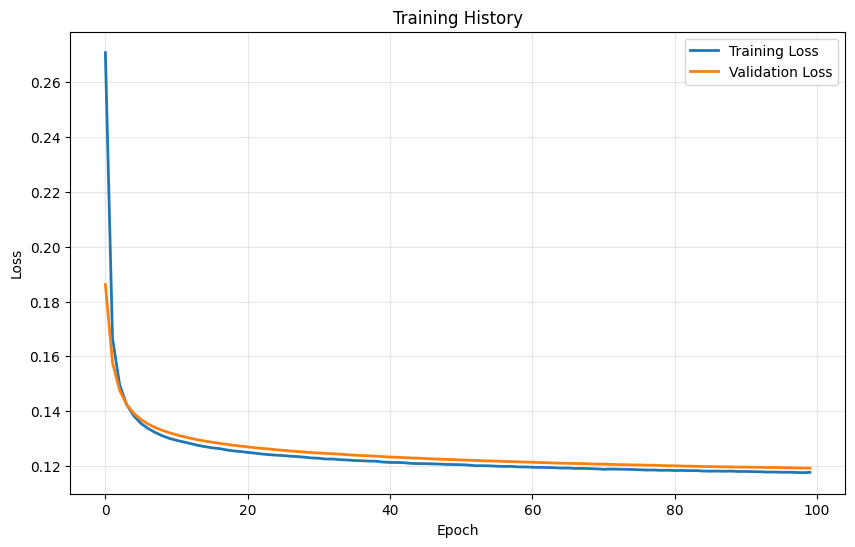


[4/4] Evaluating model on test set...

Prediction Distribution:
  Normal: 14148 (62.8%)
  Attack: 8396 (37.2%)

MODEL EVALUATION RESULTS
Accuracy:  0.7470
Precision: 0.9246
Recall:    0.6049
F1-Score:  0.7314

Confusion Matrix:
[[9078  633]
 [5070 7763]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.64      0.93      0.76      9711
      Attack       0.92      0.60      0.73     12833

    accuracy                           0.75     22544
   macro avg       0.78      0.77      0.75     22544
weighted avg       0.80      0.75      0.74     22544



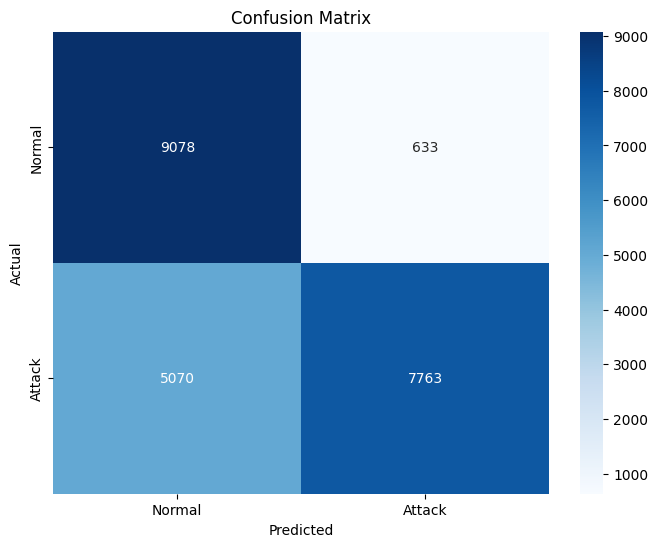


TRAINING COMPLETE!


In [121]:
from whitepossum.model import LogisticRegression

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

dataSets = {
    'nsl-kdd': {
        'train_path': 'nsl-kdd/KDDTrain+.txt',
        'test_path': 'nsl-kdd/KDDTest+.txt'
    },
    "datasplits" : {
        "raw": { "test": pd.DataFrame, "train": pd.DataFrame},
        "trad": { "test": {"X": pd.DataFrame, "y": pd.DataFrame}, "train": {"X": pd.DataFrame, "y": pd.DataFrame}},
        "combined_trad": { "test": {"X": pd.DataFrame, "y": pd.DataFrame}, "train": {"X": pd.DataFrame, "y": pd.DataFrame}},
    }
}
def load_nslkdd_data(train_path, test_path):
    """Load NSL-KDD dataset."""
    columns = [
        'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
        'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
        'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
        'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
        'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
        'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
        'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
        'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
        'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
        'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack_type', 'difficulty'
    ]

    train_df = pd.read_csv(train_path, names=columns)
    test_df = pd.read_csv(test_path, names=columns)

    print(f"Training samples: {len(train_df)}")
    print(f"Test samples: {len(test_df)}")

    return train_df, test_df


def preprocess_data(train_df, test_df, combined=False):
    """Preprocess NSL-KDD data."""
    # Create binary labels
    train_df['label'] = (train_df['attack_type'] != 'normal').astype(int)
    test_df['label'] = (test_df['attack_type'] != 'normal').astype(int)
    combined_df = pd.DataFrame()
    train_df_encoded = pd.DataFrame()
    test_df_encoded = pd.DataFrame()
    # Encode categorical features
    categorical_cols = ['protocol_type', 'service', 'flag']
    if combined:
        combined_df = pd.concat([train_df, test_df], axis=0)

    for col in categorical_cols:
        le = LabelEncoder()
        if combined:
            combined_df[col] = le.fit_transform(combined_df[col].astype(str))
        else:
            train_df[col] = le.fit_transform(train_df[col].astype(str))
            test_df[col] = le.fit_transform(test_df[col].astype(str))

    if combined:
        train_df_encoded = combined_df.iloc[:len(train_df)].copy()
        test_df_encoded = combined_df.iloc[len(train_df):].copy()

    # Separate features and labels
    if not combined:
        train_df_encoded = train_df.copy()
        test_df_encoded = test_df.copy()
    drop_cols = ['attack_type', 'difficulty', 'label']
    X_train = train_df_encoded.drop(drop_cols, axis=1).values.astype(np.float32)
    y_train = train_df['label'].values.astype(np.float32)
    X_test = test_df_encoded.drop(drop_cols, axis=1).values.astype(np.float32)
    y_test = test_df['label'].values.astype(np.float32)

    # Handle any NaN/Inf before scaling
    X_train = np.nan_to_num(X_train, nan=0.0, posinf=1e6, neginf=-1e6)
    X_test = np.nan_to_num(X_test, nan=0.0, posinf=1e6, neginf=-1e6)

    # Standardize
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Final safety check
    X_train = np.nan_to_num(X_train, nan=0.0)
    X_test = np.nan_to_num(X_test, nan=0.0)

    print(f"\nFeatures: {X_train.shape[1]}")
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Test samples: {X_test.shape[0]}")

    return X_train, X_test, y_train, y_test


def evaluate_model(model, X_test, y_test):
    """Evaluate model."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    # Check predictions
    unique, counts = np.unique(y_pred, return_counts=True)
    print("\nPrediction Distribution:")
    for u, c in zip(unique, counts):
        label = 'Normal' if u == 0 else 'Attack'
        print(f"  {label}: {c} ({c/len(y_pred)*100:.1f}%)")

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print("\n" + "="*50)
    print("MODEL EVALUATION RESULTS")
    print("="*50)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("="*50)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack'], zero_division=0))

    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }


print("="*70)
print("LOGISTIC REGRESSION FOR NETWORK INTRUSION DETECTION")
print("Dataset: NSL-KDD")
print("="*70)

# Load data
print("\n[1/4] Loading NSL-KDD dataset...")
train_df, test_df = load_nslkdd_data('nsl-kdd/KDDTrain+.txt', 'nsl-kdd/KDDTest+.txt')

# Preprocess
print("\n[2/4] Preprocessing data...")
X_train, X_test, y_train, y_test = preprocess_data(train_df, test_df)

# Split for validation
X_train_split, X_val, y_train_split, y_val = train_test_split(
X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"\nClass distribution (training):")
print(f"  Normal: {(y_train_split==0).sum()}")
print(f"  Attack: {(y_train_split==1).sum()}")

# Train
print("\n[3/4] Training Logistic Regression model...")
model = LogisticRegression(
n_features=X_train.shape[1],
learning_rate=0.01,
n_epochs=100,
batch_size=256
)

model.fit(X_train_split, y_train_split, X_val, y_val)

# Plot
model.plot_training_history()

# Evaluate
print("\n[4/4] Evaluating model on test set...")
metrics = evaluate_model(model, X_test, y_test)

print("\n" + "="*70)
print("TRAINING COMPLETE!")
print("="*70)

LOGISTIC REGRESSION FOR NETWORK INTRUSION DETECTION
Dataset: NSL-KDD

[1/4] Loading NSL-KDD dataset...


Training samples: 125973
Test samples: 22544

[2/4] Preprocessing data...

Features: 41
Training samples: 125973
Test samples: 22544
Using datasets and shuffling...

Class distribution (training):
  Normal: 53874
  Attack: 46904

[3/4] Training Logistic Regression model...
Training Logistic Regression...
Samples: 100778, Batches: 393, Epochs: 100
Epoch 10/100, Train Loss: 0.1301, Val Loss: 0.1321
Epoch 20/100, Train Loss: 0.1253, Val Loss: 0.1273
Epoch 30/100, Train Loss: 0.1230, Val Loss: 0.1249
Epoch 40/100, Train Loss: 0.1215, Val Loss: 0.1234
Epoch 50/100, Train Loss: 0.1204, Val Loss: 0.1223
Epoch 60/100, Train Loss: 0.1197, Val Loss: 0.1214
Epoch 70/100, Train Loss: 0.1189, Val Loss: 0.1207
Epoch 80/100, Train Loss: 0.1184, Val Loss: 0.1201
Epoch 90/100, Train Loss: 0.1179, Val Loss: 0.1196
Epoch 100/100, Train Loss: 0.1176, Val Loss: 0.1192


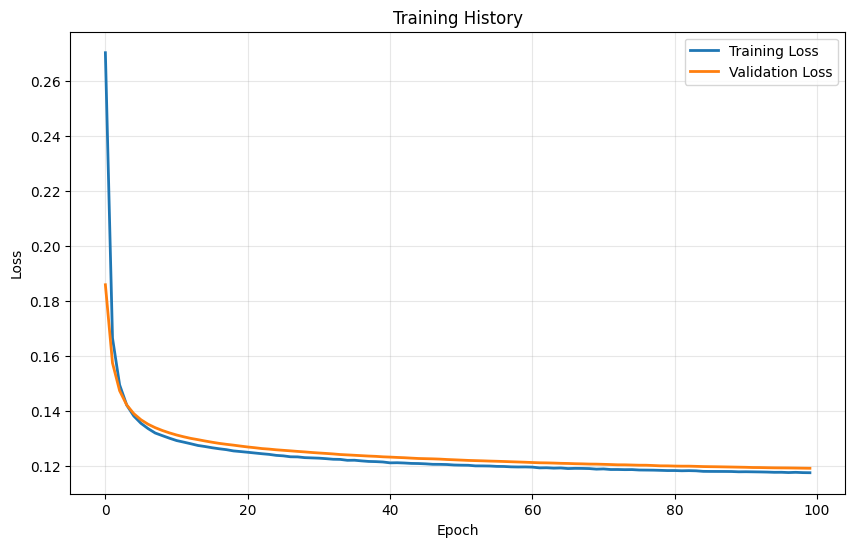


[4/4] Evaluating model on test set...

Prediction Distribution:
  Normal: 14153 (62.8%)
  Attack: 8391 (37.2%)

MODEL EVALUATION RESULTS
Accuracy:  0.7468
Precision: 0.9246
Recall:    0.6045
F1-Score:  0.7311

Confusion Matrix:
[[9078  633]
 [5075 7758]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.64      0.93      0.76      9711
      Attack       0.92      0.60      0.73     12833

    accuracy                           0.75     22544
   macro avg       0.78      0.77      0.75     22544
weighted avg       0.80      0.75      0.74     22544



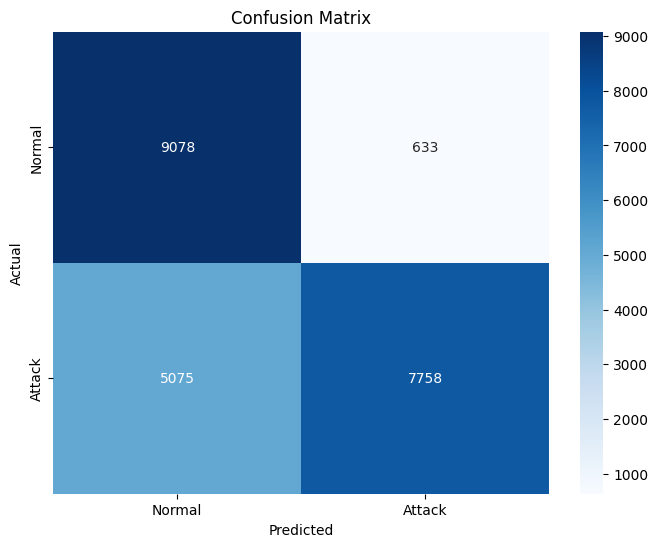

In [122]:
print("="*70)
print("LOGISTIC REGRESSION FOR NETWORK INTRUSION DETECTION")
print("Dataset: NSL-KDD")
print("="*70)

# Load data
print("\n[1/4] Loading NSL-KDD dataset...")
train_df, test_df = load_nslkdd_data('nsl-kdd/KDDTrain+.txt', 'nsl-kdd/KDDTest+.txt')

# Preprocess
print("\n[2/4] Preprocessing data...")
X_train, X_test, y_train, y_test = preprocess_data(train_df, test_df, combined=True)

print("Using datasets and shuffling...")

# Split for validation
X_train_split, X_val, y_train_split, y_val = train_test_split(
X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"\nClass distribution (training):")
print(f"  Normal: {(y_train_split==0).sum()}")
print(f"  Attack: {(y_train_split==1).sum()}")

# Train
print("\n[3/4] Training Logistic Regression model...")
model = LogisticRegression(
n_features=X_train.shape[1],
learning_rate=0.01,
n_epochs=100,
batch_size=256
)

model.fit(X_train_split, y_train_split, X_val, y_val)

# Plot
model.plot_training_history()

# Evaluate
print("\n[4/4] Evaluating model on test set...")
metrics = evaluate_model(model, X_test, y_test)

In [123]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from whitepossum import model as wpModel
import seaborn as sns

# -------------------------
# LOAD DATA
# -------------------------

column_names = [
        'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
        'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
        'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
        'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
        'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
        'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
        'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
        'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
        'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
        'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack_type', 'difficulty'
    ]

train_df = pd.read_csv("nsl-kdd/KDDTrain+.txt", names=column_names)
test_df = pd.read_csv("nsl-kdd/KDDTest+.txt", names=column_names)

def preprocessDataRandomForest(train_df, test_df, randomForestModel, combined=False):
    """Preprocess NSL-KDD data.
    Arguments:
        train_df: pd.DataFrame
            Training dataset.
        test_df: pd.DataFrame
            Testing dataset.
        combined: bool
            Whether to combine and shuffle datasets before splitting.
        randomForestModel: RandomForestClassifier
            An instance of RandomForestClassifier to be used in the pipeline.
            
     Returns: dict
            A dictionary containing preprocessed training and testing data and the model pipeline.
    """
    if randomForestModel is None:
        raise ValueError("A RandomForestClassifier instance must be provided.")
    if not isinstance(randomForestModel, RandomForestClassifier):
        raise ValueError("The provided model is not an instance of RandomForestClassifier.")
    
    # Create binary labels directly
    train_df['binary_label'] = (train_df['attack_type'] != 'normal').astype(int)
    test_df['binary_label'] = (test_df['attack_type'] != 'normal').astype(int)

    # No shuffling or concatenating
    X_train = train_df.drop(["binary_label"], axis=1)
    y_train = train_df["binary_label"]

    X_test = test_df.drop(["binary_label"], axis=1)
    y_test = test_df["binary_label"]
    
    full_df = pd.DataFrame
    X = pd.DataFrame
    y = pd.DataFrame
    
    if combined:
        print("Combining, shuffling, and spliting datasets...")
        combined_df = pd.concat([train_df, test_df], axis=0)
        full_df = shuffle(combined_df, random_state=42)
        # Split using train_test_split for proper stratification
        X = full_df.drop(["binary_label"], axis=1)
        y = full_df["binary_label"]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
    else:
        print("Using original train and test datasets...")

    categorical_cols = ["protocol_type", "service", "flag"]
    numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

    for col in numeric_cols:
        if X_train[col].dtype == 'object':  # Use string comparison
            le = LabelEncoder()
            X_train[col] = le.fit_transform(X_train[col].astype(str))
            X_test[col] = le.fit_transform(X_test[col].astype(str))
    
    preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
    )

    model = Pipeline([
        ("preprocess", preprocess),
        ("rf", randomForestModel)
    ])
    
    return {"X_train": X_train, "X_test": X_test, "y_train": y_train, "y_test": y_test, "model": model}


def trainRandomForest(rfData):
    """Train Random Forest model."""
    print("\nTraining Random Forest model...")
    rfData['model'].fit(rfData['X_train'], rfData['y_train'])
    return rfData['model']

def evaluateRandomForestModel(rfData):
    """Evaluate Random Forest model."""
    print("\nEvaluating Random Forest model on test set...")
    print()
    print()
    print("Used Random Forest Classifier with the following parameters:")
    print(rfData['model'].named_steps['rf'])
    print()
    print()
    y_pred = rfData['model'].predict(rfData['X_test'])


    print("Accuracy:", accuracy_score(rfData['y_test'], y_pred))
    print("\nClassification Report:")
    print(classification_report(rfData['y_test'], y_pred))


    print("Training set class distribution:")
    print(rfData['y_train'].value_counts())
    print("\nTest set class distribution:")
    print(rfData['y_test'].value_counts())

    cm = confusion_matrix(rfData['y_test'], y_pred, labels=[0, 1])
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", xticklabels=["normal", "attack"], yticklabels=["normal", "attack"])
    plt.title("Random Forest Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


    # from sklearn.model_selection import cross_val_score
    # scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    # print("Cross-validation scores:", scores)

Combining, shuffling, and spliting datasets...

Training Random Forest model...

Evaluating Random Forest model on test set...


Used Random Forest Classifier with the following parameters:
RandomForestClassifier(class_weight='balanced', min_samples_leaf=5,
                       min_samples_split=10, n_estimators=1000,
                       random_state=42)


Accuracy: 0.9921896040937247

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     15411
           1       0.98      1.00      0.99     14293

    accuracy                           0.99     29704
   macro avg       0.99      0.99      0.99     29704
weighted avg       0.99      0.99      0.99     29704

Training set class distribution:
binary_label
0    61643
1    57170
Name: count, dtype: int64

Test set class distribution:
binary_label
0    15411
1    14293
Name: count, dtype: int64


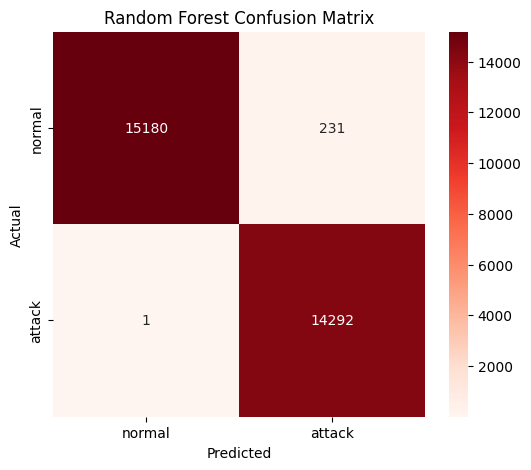

In [124]:
rf = RandomForestClassifier(
        n_estimators=1000,
        random_state=42,
        class_weight="balanced",
        min_samples_split=10,
        min_samples_leaf=5
    )
rfData = preprocessDataRandomForest(train_df, test_df, combined=True, randomForestModel=rf)
trainRandomForest(rfData)
evaluateRandomForestModel(rfData)

Combining, shuffling, and spliting datasets...

Training Random Forest model...

Evaluating Random Forest model on test set...


Used Random Forest Classifier with the following parameters:
RandomForestClassifier(class_weight='balanced', min_samples_leaf=5,
                       min_samples_split=10, n_estimators=600, random_state=52)


Accuracy: 0.9931659035820092

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     15411
           1       0.99      1.00      0.99     14293

    accuracy                           0.99     29704
   macro avg       0.99      0.99      0.99     29704
weighted avg       0.99      0.99      0.99     29704

Training set class distribution:
binary_label
0    61643
1    57170
Name: count, dtype: int64

Test set class distribution:
binary_label
0    15411
1    14293
Name: count, dtype: int64


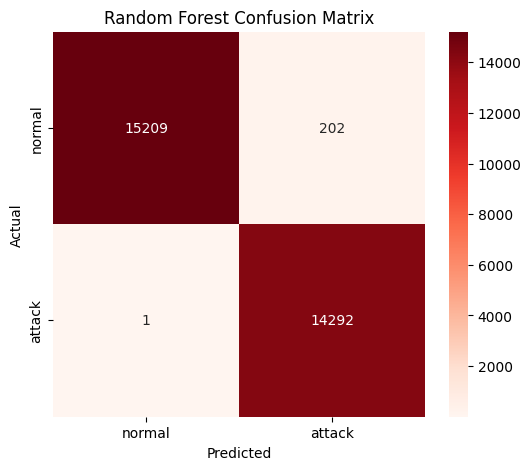

In [125]:
rf = RandomForestClassifier(
        n_estimators=600,
        random_state=52,
        class_weight="balanced",
        min_samples_split=10,
        min_samples_leaf=5
    )
rfData = preprocessDataRandomForest(train_df, test_df, combined=True, randomForestModel=rf)
trainRandomForest(rfData)
evaluateRandomForestModel(rfData)

Using original train and test datasets...

Training Random Forest model...

Evaluating Random Forest model on test set...


Used Random Forest Classifier with the following parameters:
RandomForestClassifier(class_weight='balanced', min_samples_leaf=5,
                       min_samples_split=10, n_estimators=1000,
                       random_state=42)


Accuracy: 0.8820528743789922

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.96      0.88      9711
           1       0.96      0.82      0.89     12833

    accuracy                           0.88     22544
   macro avg       0.88      0.89      0.88     22544
weighted avg       0.90      0.88      0.88     22544

Training set class distribution:
binary_label
0    67343
1    58630
Name: count, dtype: int64

Test set class distribution:
binary_label
1    12833
0     9711
Name: count, dtype: int64


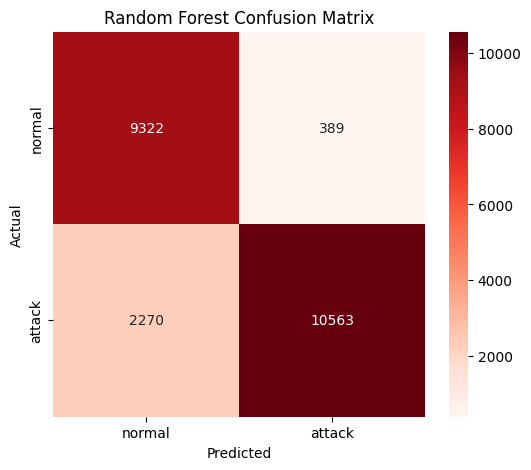

In [126]:
rf = RandomForestClassifier(
        n_estimators=1000,
        random_state=42,
        class_weight="balanced",
        min_samples_split=10,
        min_samples_leaf=5
    )
rfData = preprocessDataRandomForest(train_df, test_df, combined=False, randomForestModel=rf)
trainRandomForest(rfData)
evaluateRandomForestModel(rfData)

Using original train and test datasets...

Training Random Forest model...

Evaluating Random Forest model on test set...


Used Random Forest Classifier with the following parameters:
RandomForestClassifier(class_weight='balanced', min_samples_leaf=5,
                       min_samples_split=10, n_estimators=600, random_state=52)


Accuracy: 0.8742015613910575

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.95      0.87      9711
           1       0.96      0.82      0.88     12833

    accuracy                           0.87     22544
   macro avg       0.88      0.88      0.87     22544
weighted avg       0.89      0.87      0.87     22544

Training set class distribution:
binary_label
0    67343
1    58630
Name: count, dtype: int64

Test set class distribution:
binary_label
1    12833
0     9711
Name: count, dtype: int64


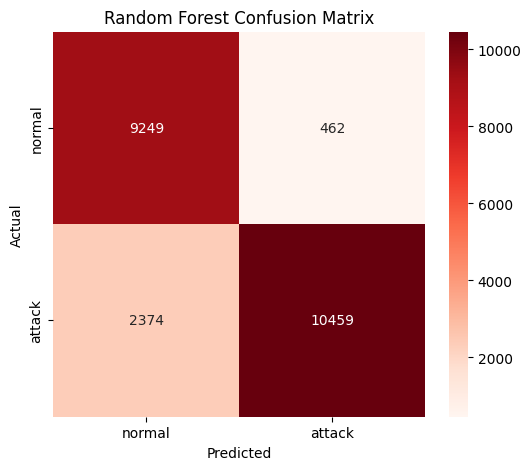

In [127]:
rf = RandomForestClassifier(
        n_estimators=600,
        random_state=52,
        class_weight="balanced",
        min_samples_split=10,
        min_samples_leaf=5
    )
rfData = preprocessDataRandomForest(train_df, test_df, combined=False, randomForestModel=rf)
trainRandomForest(rfData)
evaluateRandomForestModel(rfData)